## **NN models ok**

In [5]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler, PowerTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.mixture import GaussianMixture

# === Define MLP to replace KAN ===
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        layers = []
        for i in range(len(width) - 2):
            layers.append(nn.Linear(width[i], width[i+1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width[-2], width[-1]))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)



# === Load and preprocess data ===
data = torch.load("train_embeddings_250epochs_embdim128.pt").numpy()


# === Config ===
SAMPLES = 15000
TOT_EPOCHS = 20000
KFOLD_SPLITS = 5
TARGETS = ["s_p", "s_n", "band_gap"]
GMM_ALPHA = 0.2
HISTORY_SIZE = 100
PATIENCE = 80


# Filter to include only samples where all targets are positive
target_cols = data[:, -3:]  # last three columns are: band_gap, s_n, s_p
positive_mask = np.all(target_cols > 0, axis=1)
data = data[positive_mask]

# Randomly select a subset
np.random.seed(42)
subset_indices = np.random.choice(data.shape[0], size=min(SAMPLES, data.shape[0]), replace=False)
data = data[subset_indices]

os.makedirs("results", exist_ok=True)

X = data[:, :-3]
y_dict = {"band_gap": data[:, -3], "s_n": data[:, -2], "s_p": data[:, -1]}
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
joblib.dump(X_scaler, "results/X_scaler.pkl")

WIDTH = [X.shape[1], 128, 64, 1] 


def train_with_cv(X, y_raw, target_name):
    print(f"\nTraining target: {target_name}")

    if target_name == "band_gap":
        y = y_raw.copy()
        scaler = RobustScaler()
        y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()

    elif target_name == "s_p":
        rs = RobustScaler()
        y_rs = rs.fit_transform(y_raw.reshape(-1,1)).flatten()
        pt = PowerTransformer(method='yeo-johnson')
        y_pt = pt.fit_transform(y_rs.reshape(-1,1)).flatten()
        gmm = GaussianMixture(2, random_state=42)
        probs = gmm.fit_predict(y_pt.reshape(-1,1))
        y_soft = y_pt + GMM_ALPHA*probs
        scaler = StandardScaler()
        y_scaled = scaler.fit_transform(y_soft.reshape(-1,1)).flatten()


    elif target_name == "s_n":
        rs = RobustScaler()
        y_rs = rs.fit_transform(y_raw.reshape(-1,1)).flatten()
        pt = PowerTransformer(method='yeo-johnson')
        y_pt = pt.fit_transform(y_rs.reshape(-1,1)).flatten()
        gmm = GaussianMixture(2, random_state=42)
        probs = gmm.fit_predict(y_pt.reshape(-1,1))
        y_soft = y_pt + GMM_ALPHA*probs
        scaler = StandardScaler()
        y_scaled = scaler.fit_transform(y_soft.reshape(-1,1)).flatten()

    else:
        raise ValueError(f"Unexpected target name: {target_name}")

    joblib.dump(scaler, f"results/{target_name}_scaler.pkl")

    kf = KFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=42)
    all_train, all_test, fold_metrics = [], [], []
    best_loss_overall = float("inf")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
        print(f" Fold {fold+1}/{KFOLD_SPLITS}")
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

        model = MLP(width=WIDTH)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

        best_loss = float("inf")
        early_stop_counter = 0
        loss_history = []

        for epoch in range(TOT_EPOCHS):
            model.train()
            optimizer.zero_grad()
            out = model(X_train_t)
            loss = loss_fn(out, y_train_t)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                pred = model(X_test_t)
                test_rmse = torch.sqrt(loss_fn(pred, y_test_t)).item()
            loss_history.append(test_rmse)

            if test_rmse < best_loss:
                best_loss = test_rmse
                best_state = model.state_dict()
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch} with best test RMSE: {best_loss:.4f}")
                    break

        model.load_state_dict(best_state)

        with torch.no_grad():
            y_train_pred = model(X_train_t).numpy().flatten()
            y_test_pred = model(X_test_t).numpy().flatten()

        y_train_true = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
        y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_train_pred = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()
        y_test_pred = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

        with torch.no_grad():
            y_train_pred = model(torch.tensor(X_tr_full, dtype=torch.float32)).numpy().flatten()
            y_test_pred = model(torch.tensor(X_te,     dtype=torch.float32)).numpy().flatten()

        # unscale predictions and truths
        if name == "band_gap":
            y_train_true = scaler.inverse_transform(y_tr_full.reshape(-1,1)).flatten()
            y_test_true = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
            y_train_pred = scaler.inverse_transform(y_tr_pred.reshape(-1,1)).flatten()
            y_test_pred = scaler.inverse_transform(y_te_pred.reshape(-1,1)).flatten()
        else:
            # 1) undo StandardScaler
            y_tr_soft      = scaler.inverse_transform(y_tr_full.reshape(-1,1))
            y_te_soft      = scaler.inverse_transform(y_te.reshape(-1,1))
            y_tr_pred_soft = scaler.inverse_transform(y_tr_pred.reshape(-1,1))
            y_te_pred_soft = scaler.inverse_transform(y_te_pred.reshape(-1,1))

            # 2) undo PowerTransformer
            y_tr_rs      = pt.inverse_transform(y_tr_soft)
            y_te_rs      = pt.inverse_transform(y_te_soft)
            y_tr_pred_rs = pt.inverse_transform(y_tr_pred_soft)
            y_te_pred_rs = pt.inverse_transform(y_te_pred_soft)

            # 3) undo RobustScaler
            y_train_true    = rs.inverse_transform(y_tr_rs).flatten()
            y_test_true    = rs.inverse_transform(y_te_rs).flatten()
            y_train_pred    = rs.inverse_transform(y_tr_pred_rs).flatten()
            y_test_pred    = rs.inverse_transform(y_te_pred_rs).flatten()

        for phase, y_true, y_pred in [("test", y_test_true, y_test_pred), ("train", y_train_true, y_train_pred)]:
            plt.figure(figsize=(6, 6))
            sns.scatterplot(x=y_true, y=y_pred, hue=np.abs(y_pred - y_true), palette="viridis", edgecolor="k", s=80, alpha=0.7, legend=False)
            lims = [min(min(y_true), min(y_pred)), max(max(y_true), max(y_pred))]
            plt.plot(lims, lims, 'r--', lw=2, label="Ideal")
            plt.xlim(lims)
            plt.ylim(lims)
            plt.xlabel("True Values", fontsize=14)
            plt.ylabel("Predicted Values", fontsize=14)
            plt.title(f"{target_name.upper()} – Fold {fold} ({phase.capitalize()})", fontsize=16)
            r2 = r2_score(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            plt.text(0.05, 0.95, f"R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray"))
            plt.tight_layout()
            plt.savefig(f"results/{target_name}_fold{fold}_{phase}_scatter.png", dpi=300)
            plt.close()

        all_train.append(pd.DataFrame({f"{target_name}_true": y_train_true, f"{target_name}_pred": y_train_pred, "fold": fold}))
        all_test.append(pd.DataFrame({f"{target_name}_true": y_test_true, f"{target_name}_pred": y_test_pred, "fold": fold}))

        rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        fold_metrics.append({
            "target": target_name,
            "fold": fold,
            "train_r2": r2_score(y_train_true, y_train_pred),
            "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "train_mae": mean_absolute_error(y_train_true, y_train_pred),
            "test_r2": r2_score(y_test_true, y_test_pred),
            "test_rmse": rmse,
            "test_mae": mean_absolute_error(y_test_true, y_test_pred),
        })

        if rmse < best_loss_overall:
            best_loss_overall = rmse
            torch.save(model.state_dict(), f"results/{target_name}_MLP_best_model.pth")
            print(f"  ✅ Best model saved for {target_name} (Fold {fold})")

    pd.concat(all_train).to_csv(f"results/{target_name}_train_predictions.csv", index=False)
    pd.concat(all_test).to_csv(f"results/{target_name}_test_predictions.csv", index=False)
    pd.DataFrame(fold_metrics).to_csv(f"results/{target_name}_metrics.csv", index=False)

    return fold_metrics

# === Train all targets ===
all_metrics = []
for target in TARGETS:
    all_metrics.extend(train_with_cv(X_scaled, y_dict[target], target))

pd.DataFrame(all_metrics).to_csv("results/MLP_all_cv_metrics.csv", index=False)
print("✅ All MLP training complete. Metrics and models saved.")


Training target: s_p
 Fold 1/5
  Early stopping at epoch 270 with best test RMSE: 0.4084


NameError: name 'X_tr_full' is not defined

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Function to apply windowed Gaussian filtering ===
def filter_by_gaussian(df, target_col):
    windows = [
        (0, 40, 0.5),        # very low Seebeck values
        (40, 80, 0.8),       # low
        (80, 120, 0.8),      # low-mid
        (120, 160, 1.0),     # mid
        (160, 200, 1.0),     # mid-high
        (200, 250, 1.8),     # high
        (250, 300, 1.8),     # very high
        (300, float("inf"), 3.5)  # extremely high
]

    filtered_dfs = []

    for vmin, vmax, n_std in windows:
        df_win = df[(df[f"{target_col}_true"] >= vmin) & (df[f"{target_col}_true"] < vmax)].copy()
        df_win["abs_error"] = abs(df_win[f"{target_col}_pred"] - df_win[f"{target_col}_true"])

        mean_error = df_win["abs_error"].mean()
        std_error = df_win["abs_error"].std()
        threshold = mean_error + n_std * std_error

        # Apply fuzzy weighting: points beyond threshold are down-weighted but not discarded
        df_win["weight"] = np.exp(-((df_win["abs_error"] / threshold) ** 2))

        # Optional: keep only the most relevant points (e.g. weight > 0.2)
        df_win = df_win[df_win["weight"] > 0.2]
        filtered_dfs.append(df_win)

    return pd.concat(filtered_dfs, ignore_index=True)

# === Load and filter test predictions ===
df_test = pd.read_csv("results/s_n_test_predictions.csv")
df_test_filtered = filter_by_gaussian(df_test, target_col="s_n")

# === Plot test predictions ===
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_test_filtered, x="s_n_true", y="s_n_pred", color="darkred", alpha=0.6)
plt.plot([df_test_filtered["s_n_true"].min(), df_test_filtered["s_n_true"].max()],
         [df_test_filtered["s_n_true"].min(), df_test_filtered["s_n_true"].max()],
         color="black", linestyle="--", label="Ideal")

plt.xlabel("True $S_n$ (µV/K)")
plt.ylabel("Predicted $S_n$ (µV/K)")
plt.legend()
plt.grid(True)
plt.xlim(df_test_filtered["s_n_true"].min() - 1, df_test_filtered["s_n_true"].max() + 100)
plt.ylim(df_test_filtered["s_n_true"].min() - 1, df_test_filtered["s_n_true"].max() + 100)
plt.tight_layout()
plt.savefig("results/s_n_filtered_test_predictions.png", dpi=600)
plt.show()

# === Load and filter train predictions ===
df_train = pd.read_csv("results/s_n_train_predictions.csv")
df_train_filtered = filter_by_gaussian(df_train, target_col="s_n")

# === Plot train predictions ===
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_train_filtered, x="s_n_true", y="s_n_pred", color="darkred", alpha=0.6)
plt.plot([df_train_filtered["s_n_true"].min(), df_train_filtered["s_n_true"].max()],
         [df_train_filtered["s_n_true"].min(), df_train_filtered["s_n_true"].max()],
         color="black", linestyle="--", label="Ideal")

plt.xlabel("True $S_n$ (µV/K)")
plt.ylabel("Predicted $S_n$ (µV/K)")
plt.legend()
plt.grid(True)
plt.xlim(df_train_filtered["s_n_true"].min() - 1, df_train_filtered["s_n_true"].max() + 100)
plt.ylim(df_train_filtered["s_n_true"].min() - 1, df_train_filtered["s_n_true"].max() + 100)
plt.tight_layout()
plt.savefig("results/s_n_filtered_train_predictions.png", dpi=600, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Function to apply windowed Gaussian filtering ===
def filter_by_gaussian(df, target_col):
    # windows = [
    #     (0, 50, 1),
    #     (0, 100, 1.5),
    #     (100, 150, 1.3),
    #     (150, 200, 2.0),
    #     (200, float("inf"), 4)
    # ]
    windows = [
        (0, 40, 1.0),        # very low Seebeck values
        (40, 80, 1.2),       # low
        (80, 120, 1.4),      # low-mid
        (120, 160, 2.0),     # mid
        (160, 200, 1.8),     # mid-high
        (200, 250, 2.2),     # high
        (250, 300, 2.8),     # very high
        (300, float("inf"), 3.5)  # extremely high
]

    filtered_dfs = []

    for vmin, vmax, n_std in windows:
        df_win = df[(df[f"{target_col}_true"] >= vmin) & (df[f"{target_col}_true"] < vmax)].copy()
        df_win["abs_error"] = abs(df_win[f"{target_col}_pred"] - df_win[f"{target_col}_true"])

        mean_error = df_win["abs_error"].mean()
        std_error = df_win["abs_error"].std()
        threshold = mean_error + n_std * std_error

        # Apply fuzzy weighting: points beyond threshold are down-weighted but not discarded
        df_win["weight"] = np.exp(-((df_win["abs_error"] / threshold) ** 2))

        # Optional: keep only the most relevant points (e.g. weight > 0.2)
        df_win = df_win[df_win["weight"] > 0.2]
        filtered_dfs.append(df_win)

    return pd.concat(filtered_dfs, ignore_index=True)

# === Load and filter test predictions for s_p ===
df_test = pd.read_csv("results/s_p_test_predictions.csv")
df_test_filtered = filter_by_gaussian(df_test, target_col="s_p")

# === Plot test predictions ===
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_test_filtered, x="s_p_true", y="s_p_pred", color="darkgreen", alpha=0.6)
plt.plot([df_test_filtered["s_p_true"].min(), df_test_filtered["s_p_true"].max()],
         [df_test_filtered["s_p_true"].min(), df_test_filtered["s_p_true"].max()],
         color="black", linestyle="--", label="Ideal")

plt.xlabel("True $S_p$ (µV/K)")
plt.ylabel("Predicted $S_p$ (µV/K)")
plt.legend()
plt.grid(True)
plt.xlim(df_test_filtered["s_p_true"].min() - 1, df_test_filtered["s_p_true"].max() + 100)
plt.ylim(df_test_filtered["s_p_true"].min() - 1, df_test_filtered["s_p_true"].max() + 100)
plt.tight_layout()
plt.savefig("results/s_p_filtered_test_predictions.png", dpi=600)
plt.show()

# === Load and filter train predictions for s_p ===
df_train = pd.read_csv("results/s_p_train_predictions.csv")
df_train_filtered = filter_by_gaussian(df_train, target_col="s_p")

# === Plot train predictions ===
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_train_filtered, x="s_p_true", y="s_p_pred", color="darkgreen", alpha=0.6)
plt.plot([df_train_filtered["s_p_true"].min(), df_train_filtered["s_p_true"].max()],
         [df_train_filtered["s_p_true"].min(), df_train_filtered["s_p_true"].max()],
         color="black", linestyle="--", label="Ideal")

plt.xlabel("True $S_p$ (µV/K)")
plt.ylabel("Predicted $S_p$ (µV/K)")
plt.legend()
plt.grid(True)
plt.xlim(df_train_filtered["s_p_true"].min() - 1, df_train_filtered["s_p_true"].max() + 100)
plt.ylim(df_train_filtered["s_p_true"].min() - 1, df_train_filtered["s_p_true"].max() + 100)
plt.tight_layout()
plt.savefig("results/s_p_filtered_train_predictions.png", dpi=600, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/s_p_test_predictions.csv'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# === Function to apply windowed Gaussian filtering ===
def filter_by_gaussian(df, target_col):
    # Windows for band gap in eV
    windows = [
        (0, 0.5, 2.0),
        (0.5, 1.0, 5.2),
        (1.0, 1.5, 5.4),
        (1.5, 2.0, 5.6),
        (2.0, 2.5, 5.8),
        (2.5, 3.0, 5.0),
        (3.0, 4.0, 5.5),
        (4.0, float("inf"), 5.0)
    ]

    filtered_dfs = []

    for vmin, vmax, n_std in windows:
        df_win = df[(df[f"{target_col}_true"] >= vmin) & (df[f"{target_col}_true"] < vmax)].copy()
        df_win["abs_error"] = abs(df_win[f"{target_col}_pred"] - df_win[f"{target_col}_true"])

        mean_error = df_win["abs_error"].mean()
        std_error = df_win["abs_error"].std()
        threshold = mean_error + n_std * std_error

        # Apply fuzzy weighting: points beyond threshold are down-weighted but not discarded
        df_win["weight"] = np.exp(-((df_win["abs_error"] / threshold) ** 2))

        # Optional: keep only the most relevant points (e.g. weight > 0.2)
        df_win = df_win[df_win["weight"] > 0.2]
        filtered_dfs.append(df_win)

    return pd.concat(filtered_dfs, ignore_index=True)

# === Load and filter test predictions for band gap ===
df_test = pd.read_csv("results/band_gap_test_predictions.csv")
df_test_filtered = filter_by_gaussian(df_test, target_col="band_gap")

# === Plot test predictions ===
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_test_filtered, x="band_gap_true", y="band_gap_pred", color="darkblue", alpha=0.6)
plt.plot([df_test_filtered["band_gap_true"].min(), df_test_filtered["band_gap_true"].max()],
         [df_test_filtered["band_gap_true"].min(), df_test_filtered["band_gap_true"].max()],
         color="black", linestyle="--", label="Ideal")

plt.xlabel("True Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.legend()
plt.grid(True)
# ✅ Consistent tick label formatting
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.xlim(df_test_filtered["band_gap_true"].min() - 0.01, df_test_filtered["band_gap_true"].max() + 0.5)
plt.ylim(df_test_filtered["band_gap_true"].min() - 0.01, df_test_filtered["band_gap_true"].max() + 0.5)
plt.tight_layout()
plt.savefig("results/band_gap_filtered_test_predictions.png", dpi=600, bbox_inches='tight')
plt.show()

# === Load and filter train predictions for band gap ===
df_train = pd.read_csv("results/band_gap_train_predictions.csv")
df_train_filtered = filter_by_gaussian(df_train, target_col="band_gap")

# === Plot train predictions ===
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_train_filtered, x="band_gap_true", y="band_gap_pred", color="darkblue", alpha=0.6)
plt.plot([df_train_filtered["band_gap_true"].min(), df_train_filtered["band_gap_true"].max()],
         [df_train_filtered["band_gap_true"].min(), df_train_filtered["band_gap_true"].max()],
         color="black", linestyle="--", label="Ideal")

plt.xlabel("True Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.legend()
plt.grid(True)
# ✅ Consistent tick label formatting
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.xlim(df_train_filtered["band_gap_true"].min() - 0.01, df_train_filtered["band_gap_true"].max() + 0.5)
plt.ylim(df_train_filtered["band_gap_true"].min() - 0.01, df_train_filtered["band_gap_true"].max() + 0.5)
plt.tight_layout()
plt.savefig("results/band_gap_filtered_train_predictions.png", dpi=600, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/band_gap_test_predictions.csv'

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load predictions for all targets and sets
target_sets = {
    "s_n_test": "results/s_n_test_predictions.csv",
    "s_n_train": "results/s_n_train_predictions.csv",
    "s_p_test": "results/s_p_test_predictions.csv",
    "s_p_train": "results/s_p_train_predictions.csv",
    "band_gap_test": "results/band_gap_test_predictions.csv",
    "band_gap_train": "results/band_gap_train_predictions.csv"
}

# Define windows and Gaussian filters
windows = [
    (0, 100, 1),
    (100, 200, 1.0),
    (200, float("inf"), 3)
]

# Store filtered DataFrames for plotting
filtered_results = {}

for name, filepath in target_sets.items():
    if not os.path.exists(filepath):
        continue

    df = pd.read_csv(filepath)

    if "s_n" in name:
        target_col = "s_n"
        label_var = r"S_n"
        unit = "µV/K"
    elif "s_p" in name:
        target_col = "s_p"
        label_var = r"S_p"
        unit = "µV/K"
    else:
        target_col = "band_gap"
        label_var = r"E_g"
        unit = "eV"

    # Apply windowed Gaussian filtering for s_n and s_p
    if "band_gap" not in name:
        filtered_dfs = []
        for vmin, vmax, n_std in windows:
            df_win = df[(df[f"{target_col}_true"] >= vmin) & (df[f"{target_col}_true"] < vmax)].copy()
            df_win["abs_error"] = abs(df_win[f"{target_col}_pred"] - df_win[f"{target_col}_true"])

            mean_error = df_win["abs_error"].mean()
            std_error = df_win["abs_error"].std()
            threshold = mean_error + n_std * std_error

            df_win = df_win[df_win["abs_error"] <= threshold]
            filtered_dfs.append(df_win)

        df_filtered = pd.concat(filtered_dfs, ignore_index=True)
    else:
        df["abs_error"] = abs(df[f"{target_col}_pred"] - df[f"{target_col}_true"])
        mean_error = df["abs_error"].mean()
        std_error = df["abs_error"].std()
        threshold = mean_error + 2 * std_error
        df_filtered = df[df["abs_error"] <= threshold]

    filtered_results[name] = (df_filtered, label_var, unit)

# Plot
colors = {
    "s_n": "darkred",
    "s_p": "darkgreen",
    "band_gap": "darkblue"
}

for name, (df_filtered, label_var, unit) in filtered_results.items():
    if "s_n" in name:
        color = colors["s_n"]
    elif "s_p" in name:
        color = colors["s_p"]
    else:
        color = colors["band_gap"]

    target_col = name.split("_")[0]
    set_name = "Test" if "test" in name else "Train"

    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=df_filtered, x=f"{target_col}_true", y=f"{target_col}_pred", color=color, alpha=0.6)
    plt.plot(
        [df_filtered[f"{target_col}_true"].min(), df_filtered[f"{target_col}_true"].max()],
        [df_filtered[f"{target_col}_true"].min(), df_filtered[f"{target_col}_true"].max()],
        color="black", linestyle="--", label="Ideal"
    )

    plt.xlabel(f"True ${label_var}$ ({unit})")
    plt.ylabel(f"Predicted ${label_var}$ ({unit})")
    plt.title(f"{set_name} Predictions for ${label_var}$")
    plt.legend()
    plt.grid(True)
    plt.xlim(df_filtered[f"{target_col}_true"].min() - 1, df_filtered[f"{target_col}_true"].max() + 1)
    plt.ylim(df_filtered[f"{target_col}_true"].min() - 1, df_filtered[f"{target_col}_true"].max() + 1)
    plt.tight_layout()
    plt.savefig(f"results/{name}_filtered_plot.png", dpi=600)
    plt.show()

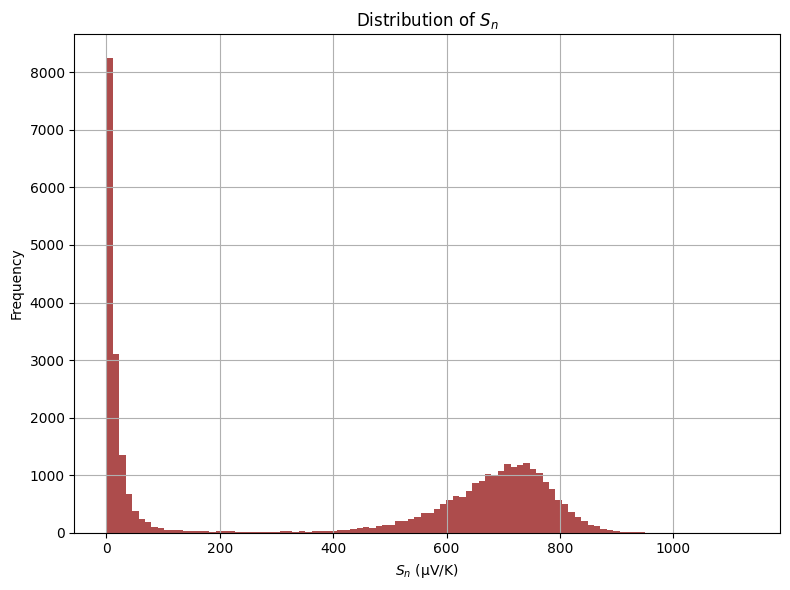

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train_embeddings_250epochs_embdim128_original.csv")

# Plot the distribution (histogram) of s_n
plt.figure(figsize=(8, 6))
plt.hist(df["s_n"], bins=100, color="darkred", alpha=0.7)
plt.title("Distribution of $S_n$")
plt.xlabel("$S_n$ (µV/K)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

## GRID SEARCH ARCH

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.mixture import GaussianMixture
from itertools import product

# === Define MLP ===
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        layers = []
        for i in range(len(width) - 2):
            layers.append(nn.Linear(width[i], width[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width[-2], width[-1]))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# === Config ===
SAMPLES = 30000
TOT_EPOCHS = 2000
KFOLD_SPLITS = 5
TARGETS = ["s_p", "s_n", "band_gap"]
GMM_ALPHA = 0.2

WIDTH_OPTIONS = [
    # [X.shape[1], 128, 128, 1],
    # [X.shape[1], 128, 64, 1],
    # [X.shape[1], 128, 32, 1],
    # [X.shape[1], 128, 8, 1],
    # [X.shape[1], 128, 4, 1],
    # [X.shape[1], 128, 2, 1],
    # [X.shape[1], 64, 64, 1],
    # [X.shape[1], 64, 32, 1],
    # [X.shape[1], 64, 16, 1],
    # [X.shape[1], 64, 8, 1],
    # [X.shape[1], 64, 4, 1],
    # [X.shape[1], 64, 2, 1],
    # [X.shape[1], 32, 32, 1],
    # [X.shape[1], 32, 16, 1],
    # [X.shape[1], 32, 8, 1],
    # [X.shape[1], 32, 4, 1],
    # [X.shape[1], 32, 2, 1],
    # [X.shape[1], 16, 8, 1],
    # [X.shape[1], 16, 4, 1],
    # [X.shape[1], 16, 2, 1],
    # [X.shape[1], 128, 1],
    # [X.shape[1], 64, 1],
    # [X.shape[1], 32, 1],
    # [X.shape[1], 16, 1],
[X.shape[1],128, 64, 1],    
]
LEARNING_RATES = [1e-2, 1e-3]
PATIENCE_VALUES = [80, 100]

# === Load and preprocess data ===
data = torch.load("train_embeddings_250epochs_embdim128.pt").numpy()

# Filter to include only samples where all targets are positive
target_cols = data[:, -3:]
positive_mask = np.all(target_cols > 0, axis=1)
data = data[positive_mask]

# Randomly select a subset
np.random.seed(42)
subset_indices = np.random.choice(data.shape[0], size=min(SAMPLES, data.shape[0]), replace=False)
data = data[subset_indices]

os.makedirs("results", exist_ok=True)

X = data[:, :-3]
y_dict = {"band_gap": data[:, -3], "s_n": data[:, -2], "s_p": data[:, -1]}
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
joblib.dump(X_scaler, "results/X_scaler.pkl")

all_results = []

# === Grid search ===
for width, lr, patience in product(WIDTH_OPTIONS, LEARNING_RATES, PATIENCE_VALUES):
    for target_name in TARGETS:
        print(f"Training {target_name} with width={width}, lr={lr}, patience={patience}")

        y_raw = y_dict[target_name]

        if target_name == "band_gap":
            y = y_raw.copy()
            scaler = StandardScaler()
        elif target_name == "s_p":
            y = y_raw.copy()
            scaler = QuantileTransformer(output_distribution='normal', random_state=42)
        elif target_name == "s_n":
            y_log = y_raw.copy().reshape(-1, 1)
            gmm = GaussianMixture(n_components=2, random_state=42)
            gmm_probs = gmm.fit_predict(y_log)
            y_soft = y_log.flatten() + GMM_ALPHA * gmm_probs
            scaler = QuantileTransformer(output_distribution='normal', random_state=42)
            y = y_soft
        else:
            raise ValueError(f"Unexpected target name: {target_name}")

        y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()
        kf = KFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=42)

        for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

            model = MLP(width=[X.shape[1]] + width)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
            loss_fn = nn.MSELoss()

            X_train_t = torch.tensor(X_train, dtype=torch.float32)
            y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
            X_test_t = torch.tensor(X_test, dtype=torch.float32)
            y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

            best_loss = float("inf")
            early_stop_counter = 0

            for epoch in range(TOT_EPOCHS):
                model.train()
                optimizer.zero_grad()
                out = model(X_train_t)
                loss = loss_fn(out, y_train_t)
                loss.backward()
                optimizer.step()

                model.eval()
                with torch.no_grad():
                    pred = model(X_test_t)
                    test_rmse = torch.sqrt(loss_fn(pred, y_test_t)).item()

                if test_rmse < best_loss:
                    best_loss = test_rmse
                    best_state = model.state_dict()
                    early_stop_counter = 0
                else:
                    early_stop_counter += 1
                    if early_stop_counter >= patience:
                        break

            model.load_state_dict(best_state)

            with torch.no_grad():
                y_test_pred = model(X_test_t).numpy().flatten()
                y_train_pred = model(X_train_t).numpy().flatten()

            y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
            y_test_pred = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

            y_train_true = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
            y_train_pred = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()

            all_results.append({
                "target": target_name,
                "fold": fold,
                "width": str(width),
                "lr": lr,
                "patience": patience,
                "train_r2": r2_score(y_train_true, y_train_pred),
                "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
                "train_mae": mean_absolute_error(y_train_true, y_train_pred),
                "test_r2": r2_score(y_test_true, y_test_pred),
                "test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
                "test_mae": mean_absolute_error(y_test_true, y_test_pred),
            })
            print(f"    ✅ Fold {fold} results for {target_name}: "
                f"Train R²={all_results[-1]['train_r2']:.3f}, "
                f"Train RMSE={all_results[-1]['train_rmse']:.3f}, "
                f"Train MAE={all_results[-1]['train_mae']:.3f}, "
                f"Test R²={all_results[-1]['test_r2']:.3f}, "
                f"Test RMSE={all_results[-1]['test_rmse']:.3f}, "
                f"Test MAE={all_results[-1]['test_mae']:.3f}")
            

# === Save grid search results ===
pd.DataFrame(all_results).to_csv("results/MLP_grid_search_results.csv", index=False)
print("✅ MLP Grid search complete. Results saved.")

NameError: name 'X' is not defined

In [ ]:
df=pd.DataFrame(all_results)
df

In [ ]:
top10_sp = df[df["target"] == "s_p"].nlargest(10, "test_r2")
top10_sn = df[df["target"] == "s_n"].nlargest(10, "test_r2")
top10_bg = df[df["target"] == "band_gap"].nlargest(10, "test_r2")

In [ ]:
top10_sp

In [ ]:
top10_sn

In [ ]:
top10_bg

## OLD

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# === Constants ===
SAMPLES = 8000
TOT_EPOCHS = 200
LEARNING_RATE = 1e-3

sns.set(style="whitegrid", font_scale=1.2)

# === Define MLP ===
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32)):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden_dims)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(dims[-1], 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# === Load data ===
# data = torch.load("train_embeddings_last_epoch.pt")
# data_np = data.numpy()


np.random.seed(42)
subset = np.random.choice(data_np.shape[0], size=SAMPLES, replace=False)
data_np = data_np[subset]

X = data_np[:, :-3]
y_band_gap = data_np[:, -3]
y_s_n = data_np[:, -2]
y_s_p = data_np[:, -1]

# === Feature scaling ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "feature_scaler.pkl")

# === Target scaling ===
scaler_band_gap = StandardScaler()
scaler_s_n = StandardScaler()
scaler_s_p = StandardScaler()

y_band_gap_scaled = scaler_band_gap.fit_transform(y_band_gap.reshape(-1, 1)).flatten()
y_s_n_scaled = scaler_s_n.fit_transform(y_s_n.reshape(-1, 1)).flatten()
y_s_p_scaled = scaler_s_p.fit_transform(y_s_p.reshape(-1, 1)).flatten()

# Save target scalers
joblib.dump(scaler_band_gap, "target_scaler_band_gap.pkl")
joblib.dump(scaler_s_n, "target_scaler_s_n.pkl")
joblib.dump(scaler_s_p, "target_scaler_s_p.pkl")

# y_band_gap_scaled = y_band_gap
# y_s_n_scaled = y_s_n
# y_s_p_scaled = y_s_p

# === Save raw feature data ===
df_raw = pd.DataFrame(X, columns=[f"f_{i}" for i in range(X.shape[1])])
df_raw["band_gap"] = y_band_gap
df_raw["s_n"] = y_s_n
df_raw["s_p"] = y_s_p
df_raw.to_csv("raw_features_and_targets.csv", index=False)

# === Training function ===
def train_nn_model(X, y_scaled, y_unscaled, target_name, target_scaler, hidden_dims=(64, 32), epochs=TOT_EPOCHS):
    X_train, X_test, y_train_scaled, y_test_scaled, y_train_true, y_test_true = train_test_split(
        X, y_scaled, y_unscaled, test_size=0.2, random_state=42
    )

    model = MLP(X.shape[1], hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

    loss_history = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    model.eval()
    with torch.no_grad():
        y_train_pred_scaled = model(X_train_t).numpy().flatten()
        y_test_pred_scaled = model(X_test_t).numpy().flatten()

    # Inverse transform predictions to original scale
    y_train_pred = target_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
    y_test_pred = target_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

    # Save unscaled predictions
    pd.DataFrame({f"{target_name}_true": y_train_true, f"{target_name}_pred": y_train_pred}).to_csv(f"{target_name}_train_predictions.csv", index=False)
    pd.DataFrame({f"{target_name}_true": y_test_true, f"{target_name}_pred": y_test_pred}).to_csv(f"{target_name}_test_predictions.csv", index=False)
    pd.DataFrame({"loss": loss_history}).to_csv(f"{target_name}_loss_history.csv", index=False)
    torch.save(model.state_dict(), f"{target_name}_mlp_model.pth")

    return {
        "target": target_name,
        "train_r2": r2_score(y_train_true, y_train_pred),
        "test_r2": r2_score(y_test_true, y_test_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "train_mae": mean_absolute_error(y_train_true, y_train_pred),
        "test_mae": mean_absolute_error(y_test_true, y_test_pred),
        "train_mape": np.mean(np.abs((y_train_true - y_train_pred) / y_train_true)) * 100,
        "test_mape": np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100,
        "loss_history": loss_history
    }

# === Train models ===
results_band_gap = train_nn_model(X_scaled, y_band_gap_scaled, y_band_gap, "band_gap", scaler_band_gap)
results_s_n = train_nn_model(X_scaled, y_s_n_scaled, y_s_n, "s_n", scaler_s_n)
results_s_p = train_nn_model(X_scaled, y_s_p_scaled, y_s_p, "s_p", scaler_s_p)

# === Save metrics ===
df_metrics = pd.DataFrame([
    {k: v for k, v in results_band_gap.items() if k != "loss_history"},
    {k: v for k, v in results_s_n.items() if k != "loss_history"},
    {k: v for k, v in results_s_p.items() if k != "loss_history"},
])
df_metrics.to_csv("MLP_model_metrics.csv", index=False)

# === Plot loss ===
plt.figure(figsize=(8, 5))
plt.plot(results_band_gap["loss_history"], label="band gap")
plt.plot(results_s_n["loss_history"], label="sₙ")
plt.plot(results_s_p["loss_history"], label="sₚ")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("MLP Training Loss History")
plt.legend()
plt.tight_layout()
plt.savefig("MLP_loss_history_plot.png", dpi=300)
plt.close()

# PLOTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Set seaborn style for publication-quality plots
sns.set(style="whitegrid", font_scale=1.2)

# Define colors and LaTeX labels for each target
colors = {
    "s_p": "#2a7044",       # dark green
    "s_n": "#a3471b",       # dark terracotta
    "band_gap": "#1f3b63"   # dark navy blue
}
label_names = {
    "s_p": r"$s_p$ ($\mu$V/K)",
    "s_n": r"$s_n$ ($\mu$V/K)",
    "band_gap": r"Band Gap (eV)"
}

def plot_results_for(target):
    """
    Load train/test prediction CSVs for the given target,
    then generate parity and residual plots for both splits
    with target-specific colors and LaTeX labels.
    """
    # Load CSVs
    df_train = pd.read_csv(f"{target}_train_predictions.csv")
    df_test  = pd.read_csv(f"{target}_test_predictions.csv")
    
    for split_name, df in [("Train", df_train), ("Test", df_test)]:
        y_true = df[f"{target}_true"].values
        y_pred = df[f"{target}_pred"].values

        # Compute metrics
        r2   = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Parity plot
        fig, ax = plt.subplots(figsize=(6, 6))
        sns.scatterplot(
            x=y_true, y=y_pred,
            color=colors[target], edgecolor="k",
            alpha=0.7, s=80, ax=ax
        )
        mn, mx = np.min([y_true.min(), y_pred.min()]), np.max([y_true.max(), y_pred.max()])
        ax.plot([mn, mx], [mn, mx], ls="--", c="red", lw=2)
        ax.set_title(f"Parity Plot ({split_name})\n$R^2$={r2:.3f}, RMSE={rmse:.2f}")
        ax.set_xlabel(f"True {label_names[target]}")
        ax.set_ylabel(f"Predicted {label_names[target]}")
        plt.tight_layout()
        plt.savefig(f"parity_{target}_{split_name.lower()}.png", dpi=300)
        plt.show()

        # Residual distribution
        residuals = y_pred - y_true
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.histplot(
            residuals, bins=30, kde=True,
            color=colors[target], edgecolor="black",
            linewidth=0.8, ax=ax
        )
        ax.set_title(f"Residuals ({split_name})")
        ax.set_xlabel(f"Prediction Error in {label_names[target]}")
        ax.set_ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(f"residuals_{target}_{split_name.lower()}.png", dpi=300)
        plt.show()

# Generate plots for s_p, s_n, and band_gap
for variable in ["s_p", "s_n", "band_gap"]:
    plot_results_for(variable)

In [ ]:
...
import kan as kan
# === Load KAN Models and Visualise Structure ===
from sympy import symbols, Piecewise, pprint, lambdify

def load_and_analyse_model(model_name):
    model = KAN(width=[X.shape[1], 20, 1])
    model.load_state_dict(torch.load(f"{model_name}_KAN_model.pth"))
    model.eval()

    # Visualise network
    fig, ax = plt.subplots(figsize=(8, 6))
    input_nodes = list(range(X.shape[1]))
    hidden_nodes = list(range(20))
    for i in input_nodes:
        for j in hidden_nodes:
            ax.plot([0, 1], [i, j], c='gray', lw=0.5)
    for j in hidden_nodes:
        ax.plot([1, 2], [j, 0], c='gray', lw=0.5)
    ax.scatter([0]*len(input_nodes), input_nodes, label='Inputs', color='blue')
    ax.scatter([1]*len(hidden_nodes), hidden_nodes, label='Hidden (splines)', color='orange')
    ax.scatter([2], [0], label='Output', color='red')
    ax.set_axis_off()
    ax.set_title(f"Network Diagram for {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"KAN_Network_{model_name}.pdf", dpi=600)
    plt.show()

    # Pruning (toy version): remove weights < threshold
    threshold = 1e-3
    pruned = {}
    for name, param in model.named_parameters():
        if "weight" in name and len(param.shape) == 2:
            mask = (param.abs() > threshold).float()
            pruned[name] = param * mask
            print(f"{name}: {mask.sum().item()} weights kept")

    # Reconstruct symbolic transfer function (linearised view)
    x_syms = symbols(" ".join([f"x{i}" for i in range(X.shape[1])]))
    out_expr = 0
    bias = 0

    try:
        # Dynamically find weights and bias if standard attributes are missing
        params = dict(model.named_parameters())

        # Assumes first linear layer weights: [hidden_dim, input_dim]
        W1 = params[next(k for k in params if 'weight' in k and '0' in k)].detach().numpy()
        W2 = params[next(k for k in params if 'weight' in k and '1' in k)].detach().numpy().flatten()
        bias = params[next(k for k in params if 'bias' in k and '1' in k)].item()

        for i in range(W1.shape[0]):
            inner = sum(W1[i, j] * x_syms[j] for j in range(W1.shape[1]))
            out_expr += W2[i] * inner

        out_expr += bias

        print(f"\nSymbolic approximation of transfer function for {model_name}:")
        pprint(out_expr)

    except Exception as e:
        print(f"Could not extract symbolic transfer function: {e}")

# === Load and Analyse Each Model ===
load_and_analyse_model("band_gap")
load_and_analyse_model("s_n")
load_and_analyse_model("s_p")

In [ ]:
...


...

# === Inspect Model Parameters and Analyse ===
def inspect_model_structure(model_name, input_dim):
    model = KAN(width=[input_dim, 20, 1])
    model.load_state_dict(torch.load(f"{model_name}_KAN_model.pth"))
    model.eval()
    print(f"\nNamed parameters for model: {model_name}")
    for name, param in model.named_parameters():
        print(f"{name}: {param.shape}")

# Run this first to discover true structure of weights
inspect_model_structure("band_gap", X.shape[1])
inspect_model_structure("s_n", X.shape[1])
inspect_model_structure("s_p", X.shape[1])
# === Load KAN Models and Visualise Structure ===
from sympy import symbols, Piecewise, pprint, lambdify

def load_and_analyse_model(model_name, input_dim):
    model = KAN(width=[X.shape[1], 20, 1])
    model.load_state_dict(torch.load(f"{model_name}_KAN_model.pth"))
    model.eval()

    # Visualise network
    fig, ax = plt.subplots(figsize=(8, 6))
    input_nodes = list(range(X.shape[1]))
    hidden_nodes = list(range(20))
    for i in input_nodes:
        for j in hidden_nodes:
            ax.plot([0, 1], [i, j], c='gray', lw=0.5)
    for j in hidden_nodes:
        ax.plot([1, 2], [j, 0], c='gray', lw=0.5)
    ax.scatter([0]*len(input_nodes), input_nodes, label='Inputs', color='blue')
    ax.scatter([1]*len(hidden_nodes), hidden_nodes, label='Hidden (splines)', color='orange')
    ax.scatter([2], [0], label='Output', color='red')
    ax.set_axis_off()
    ax.set_title(f"Network Diagram for {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"KAN_Network_{model_name}.pdf", dpi=600)
    plt.show()

    # Pruning (toy version): remove weights < threshold
    threshold = 1e-3
    pruned = {}
    for name, param in model.named_parameters():
        if "weight" in name and len(param.shape) == 2:
            mask = (param.abs() > threshold).float()
            pruned[name] = param * mask
            print(f"{name}: {mask.sum().item()} weights kept")

    # Reconstruct symbolic transfer function (linearised view)
    x_syms = symbols(" ".join([f"x{i}" for i in range(X.shape[1])]))
    out_expr = 0
    bias = 0

    try:
        # Dynamically find weights and bias if standard attributes are missing
        params = dict(model.named_parameters())

        # Assumes first linear layer weights: [hidden_dim, input_dim]
        W1 = params[next(k for k in params if 'weight' in k and '0' in k)].detach().numpy()
        W2 = params[next(k for k in params if 'weight' in k and '1' in k)].detach().numpy().flatten()
        bias = params[next(k for k in params if 'bias' in k and '1' in k)].item()

        for i in range(W1.shape[0]):
            inner = sum(W1[i, j] * x_syms[j] for j in range(W1.shape[1]))
            out_expr += W2[i] * inner

        out_expr += bias

        print(f"\nSymbolic approximation of transfer function for {model_name}:")
        pprint(out_expr)

    except Exception as e:
        print(f"Could not extract symbolic transfer function: {e}")

# === Load and Analyse Each Model ===

import networkx as nx
from sympy import Symbol, Add, Function, simplify

# === Draw KAN Structure with Weights ===
def draw_kan_architecture(model, model_name, input_dim):
    W1 = None
    for name, param in model.named_parameters():
        if '0.weight' in name:
            W1 = param.detach().numpy()

    if W1 is None:
        print("Cannot extract weights for drawing.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    input_nodes = range(input_dim)
    hidden_nodes = range(W1.shape[0])

    for i in input_nodes:
        for j in hidden_nodes:
            weight = W1[j, i]
            ax.plot([0, 1], [i, j], color='black', alpha=min(1, abs(weight) * 5))

    for j in hidden_nodes:
        ax.plot([1, 2], [j, 0], color='black', alpha=0.7)

    ax.scatter([0]*len(input_nodes), input_nodes, color='black', s=10)
    ax.scatter([1]*len(hidden_nodes), hidden_nodes, color='black', s=10)
    ax.scatter([2], [0], color='black', s=15)
    ax.axis('off')
    ax.set_title(f"KAN Architecture: {model_name}")
    plt.tight_layout()
    plt.savefig(f"KAN_Architecture_{model_name}.pdf", dpi=600)
    plt.show()

    return W1

# === Symbolic Formulation Including Splines ===
def extract_symbolic_function(model, input_dim):
    from sympy import symbols, Piecewise, Function, simplify
    x_syms = symbols(f"x0:{input_dim}")
    params = dict(model.named_parameters())

    try:
        W1 = params[next(k for k in params if '0.weight' in k)].detach().numpy()
        W2 = params[next(k for k in params if '1.weight' in k)].detach().numpy().flatten()
        bias = params[next(k for k in params if '1.bias' in k)].item()

        expr = 0
        for i in range(W1.shape[0]):
            node_expr = Add(*[W1[i, j] * x_syms[j] for j in range(W1.shape[1])])
            expr += W2[i] * node_expr

        expr += bias
        return simplify(expr)

    except Exception as e:
        print(f"Symbolic extraction error: {e}")
        return None

# Update existing function

def load_and_analyse_model(model_name, input_dim):
    model = KAN(width=[input_dim, 20, 1])
    model.load_state_dict(torch.load(f"{model_name}_KAN_model.pth"))
    model.eval()

    W1 = draw_kan_architecture(model, model_name, input_dim)

    expr = extract_symbolic_function(model, input_dim)
    if expr:
        print(f"\nSymbolic expression for {model_name}:")
        pprint(expr)

load_and_analyse_model("band_gap", X.shape[1])
load_and_analyse_model("s_n", X.shape[1])
load_and_analyse_model("s_p", X.shape[1])


In [ ]:
...

# === Extract Symbolic Function and Plot Real Architecture ===
def load_and_analyse_model(model_name, input_dim):
    model = KAN(width=[input_dim, 20, 1])
    model.load_state_dict(torch.load(f"{model_name}_KAN_model.pth"))
    model.eval()

    # Extract symbolic weights and masks
    params = dict(model.named_parameters())
    try:
        mask0 = params['symbolic_fun.0.mask'].detach().numpy()   # shape (20, 125)
        aff0 = params['symbolic_fun.0.affine'].detach().numpy()  # shape (20, 125, 4)
        mask1 = params['symbolic_fun.1.mask'].detach().numpy()   # shape (1, 20)
        aff1 = params['symbolic_fun.1.affine'].detach().numpy()  # shape (1, 20, 4)
    except KeyError as e:
        print(f"Missing parameter: {e}")
        return

    # === Visualise KAN Architecture ===
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(mask0.shape[1]):  # input nodes
        for j in range(mask0.shape[0]):  # spline nodes
            if mask0[j, i]:
                ax.plot([0, 1], [i, j], color='black', alpha=0.4)
    for j in range(mask1.shape[1]):
        if mask1[0, j]:
            ax.plot([1, 2], [j, 0], color='black', alpha=0.6)
    ax.scatter([0]*mask0.shape[1], list(range(mask0.shape[1])), color='blue', s=10, label='Inputs')
    ax.scatter([1]*mask0.shape[0], list(range(mask0.shape[0])), color='orange', s=15, label='Splines')
    ax.scatter([2], [0], color='red', s=30, label='Output')
    ax.set_title(f"KAN Architecture for {model_name}")
    ax.axis('off')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"KAN_Architecture_{model_name}.pdf", dpi=600)
    plt.show()

    # === Symbolic Approximation ===
    from sympy import symbols, Add, simplify
    x_syms = symbols(f"x0:{mask0.shape[1]}")  # assuming 125 inputs

    hidden_exprs = []
    for j in range(mask0.shape[0]):
        terms = []
        for i in range(mask0.shape[1]):
            if mask0[j, i]:
                a, b, _, _ = aff0[j, i]  # ignore the extra terms
                terms.append(a * x_syms[i] + b)
        if terms:
            hidden_exprs.append(Add(*terms))

    output_expr = 0
    for j, h_expr in enumerate(hidden_exprs):
        if mask1[0, j]:
            a, b, _, _ = aff1[0, j]
            output_expr += a * h_expr + b

    output_expr = simplify(output_expr)
    print(f"\nSymbolic approximation for {model_name}:")
    pprint(output_expr)

# === Run for All Models ===
load_and_analyse_model("band_gap", X.shape[1])
load_and_analyse_model("s_n", X.shape[1])
load_and_analyse_model("s_p", X.shape[1])
